# SPEC 07 — RefSeq-based LIN28A Binding-Site Region Classification

**Goal**: Map each Table S3A binding-site position to 5′UTR / CDS / 3′UTR using
UCSC mm9 refGene annotation, then test whether binding region associates with
ribosome density change.

**External annotation**: UCSC mm9 refGene
- URL: `http://hgdownload.soe.ucsc.edu/goldenPath/mm9/database/refGene.txt.gz`
- Saved: `lin28a_project/data/annotations/mm9_refGene.txt.gz`
- Type: **public external annotation reference** (not raw sequencing data)
- Provenance: `notes/07_annotation_provenance.md`

**Position coordinate assumption**: 1-based exonic transcript coordinate from 5′ end.
Validated by out_of_bounds rate (0.14%) and example transcript checks.

**Analysis mode**: Standard (match rate = 98.8%)

In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import scipy.stats as stats
import sys

BASE  = '/home/sezero/data/BI_2026-1/Guided_Mission_1/colab-biolab/lin28a_project'
OUT_T = f'{BASE}/results/tables'
OUT_F = f'{BASE}/results/figures'

ribo_col = 'Ribosome density change (log2)'

print(f'Python: {sys.version}')
print(f'pandas: {pd.__version__}  scipy: {__import__("scipy").__version__}')

Python: 3.10.20 (main, Mar 11 2026, 17:46:40) [GCC 14.3.0]
pandas: 2.3.3  scipy: 1.15.3


## 1. refGene match rate and Position validation

In [2]:
df_match = pd.read_csv(f'{OUT_T}/07_match_rate_report.csv')
print('Match rate report:')
df_match

Match rate report:


,s3a_unique_transcripts,refgene_unique_nm_ids,matched_transcripts,unmatched_transcripts,match_rate_pct,s3a_sites_in_matched_tx,s3a_sites_in_unmatched_tx,site_coverage_pct
0,6606,45714,6524,82,98.76,64760,774,98.82


In [3]:
# Position coordinate validation for example transcripts
df_feat = pd.read_csv(f'{OUT_T}/07_transcript_feature_lengths.csv')
examples = ['NM_016783','NM_008477','NM_021495']  # Pgrmc1, Ktn1, Pvrl3
genes    = {'NM_016783':'Pgrmc1', 'NM_008477':'Ktn1', 'NM_021495':'Pvrl3(Nectin3)'}

df_s3 = pd.read_csv(f'{OUT_T}/07_s3_binding_region_classification.csv')

print(f'out_of_bounds sites: {(df_s3["binding_region"]=="out_of_bounds").sum()} '
      f'({(df_s3["binding_region"]=="out_of_bounds").mean()*100:.2f}%)')
print()
for nm in examples:
    feat = df_feat[df_feat['name'] == nm]
    s3_sub = df_s3[df_s3['Transcript'] == nm]
    if len(feat) == 0:
        print(f'{nm}: not in refGene'); continue
    f = feat.iloc[0]
    print(f"{genes[nm]} ({nm}):")
    print(f"  total_exonic={f['total_exonic_len']}, "
          f"5'UTR={f['five_utr_len']}, CDS={f['cds_len']}, 3'UTR={f['three_utr_len']}")
    print(f"  S3A sites n={len(s3_sub)}, pos range "
          f"{s3_sub['Position'].min():.0f}–{s3_sub['Position'].max():.0f}")
    print(f"  regions: {s3_sub['binding_region'].value_counts().to_dict()}")
    print()

out_of_bounds sites: 91 (0.14%)

Pgrmc1 (NM_016783):
  total_exonic=1870, 5'UTR=94, CDS=588, 3'UTR=1188
  S3A sites n=21, pos range 74–1803
  regions: {'3UTR': 16, 'CDS': 4, '5UTR': 1}

Ktn1 (NM_008477):
  total_exonic=4485, 5'UTR=31, CDS=3984, 3'UTR=470
  S3A sites n=62, pos range 33–4437
  regions: {'CDS': 57, '3UTR': 5}

Pvrl3(Nectin3) (NM_021495):
  total_exonic=3070, 5'UTR=193, CDS=1650, 3'UTR=1227
  S3A sites n=17, pos range 376–1713
  regions: {'CDS': 17}



## 2. Site-level binding region distribution (Figure 07-1)

**Site-level**: each binding site counted once based on its transcript position.

This is **distinct** from the transcript-level dominant region analysis (Section 3).

| Region | Color |
|---|---|
| 5′UTR | Blue |
| CDS | Teal |
| 3′UTR | Red |
| ncRNA | Gray |

In [4]:
df_site_sum = pd.read_csv(f'{OUT_T}/07_binding_region_summary_by_candidate_group.csv')
df_site_sum[['candidate_group','n_sites',
             'n_5UTR','frac_5UTR','n_CDS','frac_CDS','n_3UTR','frac_3UTR','n_ncRNA','frac_ncRNA']]

,candidate_group,n_sites,n_5UTR,frac_5UTR,n_CDS,frac_CDS,n_3UTR,frac_3UTR,n_ncRNA,frac_ncRNA
0,Not_candidate,63239,1479,0.023387,41306,0.653173,19989,0.316087,465,0.007353
1,A_only,443,3,0.006772,382,0.862302,58,0.130926,0,0.000000
2,B_only,0,0,NaN,0,NaN,0,NaN,0,NaN
3,A_and_B_overlap,987,19,0.019250,577,0.584600,391,0.396150,0,0.000000
4,ALL_matched,64669,1501,0.023211,42265,0.653559,20438,0.316040,465,0.007190


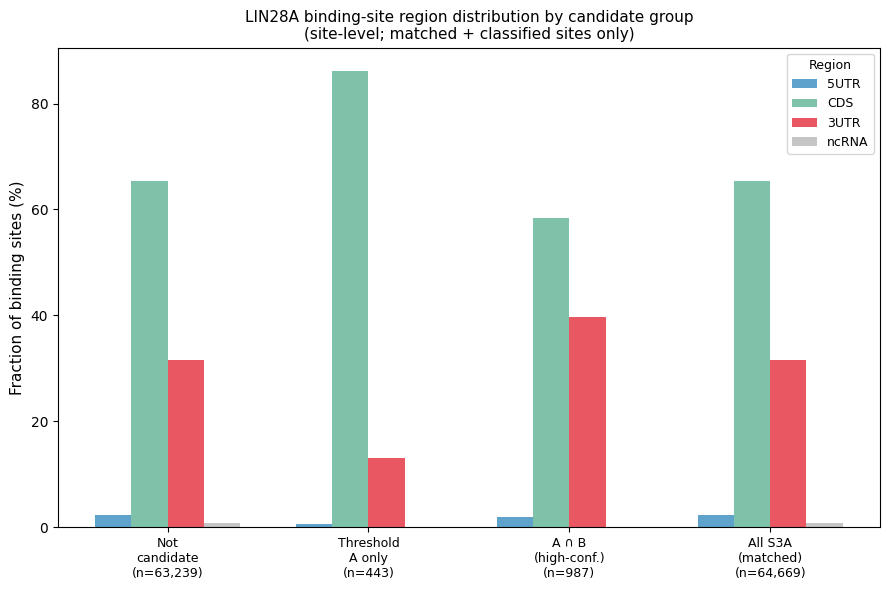

In [5]:
REGIONS = ['5UTR', 'CDS', '3UTR', 'ncRNA']
REGION_COLORS = {'5UTR': '#4393C3', 'CDS': '#67B99A', '3UTR': '#E63946', 'ncRNA': '#BBBBBB'}
GRP_LABELS = {
    'Not_candidate': 'Not\ncandidate',
    'A_only': 'Threshold\nA only',
    'B_only': 'Threshold\nB only',
    'A_and_B_overlap': 'A ∩ B\n(high-conf.)',
    'ALL_matched': 'All S3A\n(matched)',
}
grps_to_plot = ['Not_candidate', 'A_only', 'A_and_B_overlap', 'ALL_matched']
plot_df = df_site_sum[df_site_sum['candidate_group'].isin(grps_to_plot)].set_index('candidate_group')

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(grps_to_plot))
bar_width = 0.18
for i, reg in enumerate(REGIONS):
    vals = [float(plot_df.loc[g, f'frac_{reg}']) * 100
            if g in plot_df.index else 0 for g in grps_to_plot]
    ax.bar(x + i * bar_width, vals, bar_width,
           color=REGION_COLORS[reg], label=reg, alpha=0.85)
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(
    [GRP_LABELS[g] + (f'\n(n={int(plot_df.loc[g, "n_sites"]):,})'
                      if g in plot_df.index else '')
     for g in grps_to_plot],
    fontsize=9)
ax.set_ylabel('Fraction of binding sites (%)', fontsize=11)
ax.set_title('LIN28A binding-site region distribution by candidate group\n'
             '(site-level; matched + classified sites only)', fontsize=11)
ax.legend(title='Region', fontsize=9, title_fontsize=9)
fig.tight_layout()
fig.savefig(f'{OUT_F}/07_binding_region_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. Transcript-level dominant binding region vs ribosome density change (Figure 07-2)

**Transcript-level**: each transcript assigned the region with the **most binding sites**.
This is **strictly separate** from the site-level analysis above.

Left panel: all transcripts with ribosome data. Right panel: A∩B high-confidence candidates only.

In [6]:
df_dom = pd.read_csv(f'{OUT_T}/07_ribo_change_by_dominant_binding_region.csv')
df_dom

,dominant_binding_region,n_all,median_ribo_all,mean_ribo_all,n_hc,median_ribo_hc,mean_ribo_hc
0,5UTR,24,-0.088317,-0.160058,0,NaN,NaN
1,CDS,2812,-0.361793,-0.334343,21,0.797070,0.743208
2,3UTR,867,-0.151171,-0.131756,13,0.680821,0.685995
3,tie,271,-0.251987,-0.277096,0,NaN,NaN


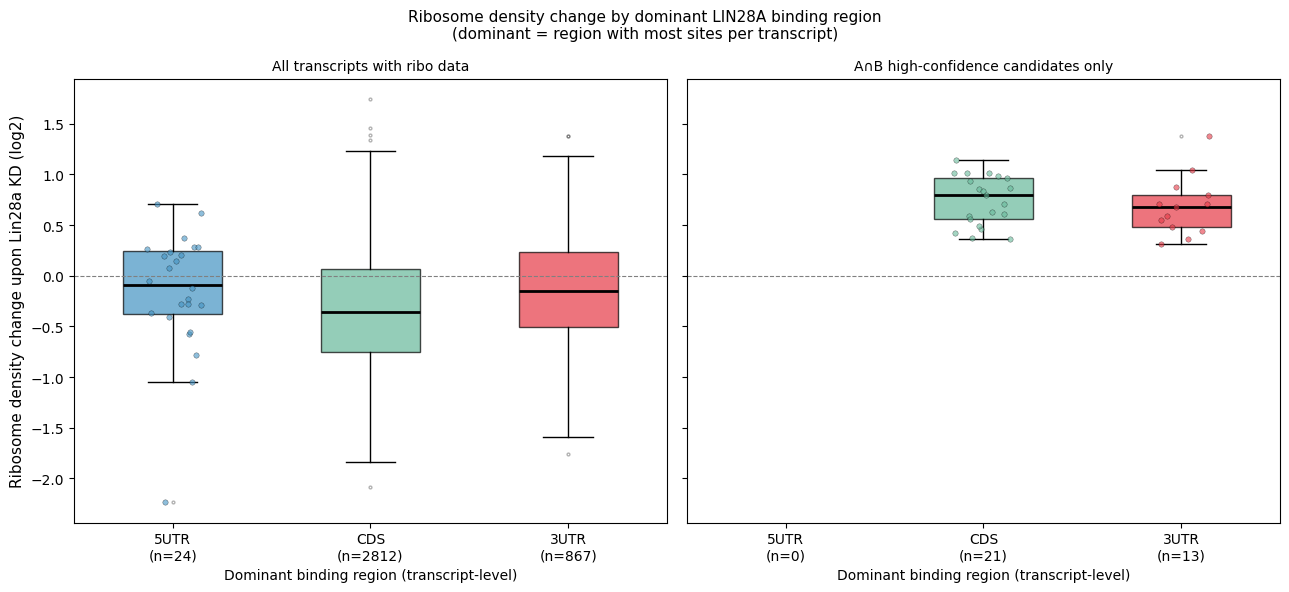

In [7]:
df_s3_class = pd.read_csv(f'{OUT_T}/07_s3_binding_region_classification.csv')
df_A  = pd.read_csv(f'{OUT_T}/03_direct_candidates_threshold_A.csv')
df_B  = pd.read_csv(f'{OUT_T}/03_direct_candidates_threshold_B.csv')
df_s5 = pd.read_csv(f'{BASE}/data/processed/table_s5_cleaned.csv')

acc_HC = set(df_A['Accession']) & set(df_B['Accession'])
clip_enr_cols = [c for c in df_s5.columns
    if ('CLIP-seq enrichment' in c) and ('log2' in c)
    and any(r in c for r in ['35L33G','2J3','polyclonal'])]
for c in clip_enr_cols:
    df_s5[c] = pd.to_numeric(df_s5[c], errors='coerce')
df_s5['mean_CLIP_enrichment'] = df_s5[clip_enr_cols].mean(axis=1)
df_s5[ribo_col] = pd.to_numeric(df_s5[ribo_col], errors='coerce')
def cand_group(acc):
    if acc in acc_HC: return 'A_and_B_overlap'
    if acc in set(df_A['Accession']): return 'A_only'
    return 'Not_candidate'
df_s5['candidate_group'] = df_s5['Accession'].map(cand_group)

# Classified binding sites only
s3c = df_s3_class[df_s3_class['binding_region'].isin(['5UTR','CDS','3UTR','ncRNA'])].copy()
tx_to_cg = df_s5.set_index('Accession')['candidate_group'].to_dict()
s3c['candidate_group'] = s3c['Transcript'].map(tx_to_cg).fillna('Not_candidate')

REGIONS = ['5UTR', 'CDS', '3UTR', 'ncRNA']
tx_reg = (s3c.groupby(['Transcript','binding_region']).size()
          .unstack(fill_value=0).reset_index())
for reg in REGIONS:
    if reg not in tx_reg.columns: tx_reg[reg] = 0
def dom_reg(row):
    counts = {r: row[r] for r in REGIONS}
    mx = max(counts.values())
    if mx == 0: return 'none'
    top = [r for r, c in counts.items() if c == mx]
    return top[0] if len(top) == 1 else 'tie'
tx_reg['dominant_binding_region'] = tx_reg.apply(dom_reg, axis=1)
tx_reg.rename(columns={'Transcript': 'Accession'}, inplace=True)
tx_r_s5 = tx_reg.merge(df_s5[['Accession', ribo_col, 'candidate_group']], on='Accession', how='left')

sub_ribo    = tx_r_s5.dropna(subset=[ribo_col])
sub_ribo_hc = sub_ribo[sub_ribo['candidate_group'] == 'A_and_B_overlap']
dom_regs_plot = [r for r in REGIONS
                 if r in sub_ribo['dominant_binding_region'].values]
REGION_COLORS = {'5UTR':'#4393C3','CDS':'#67B99A','3UTR':'#E63946','ncRNA':'#BBBBBB'}

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
for ax, (sub_data, title_sfx) in zip(
        axes,
        [(sub_ribo, 'All transcripts with ribo data'),
         (sub_ribo_hc, 'A∩B high-confidence candidates only')]):
    data_by_reg = [sub_data[sub_data['dominant_binding_region'] == r][ribo_col].dropna().values
                   for r in dom_regs_plot]
    n_by_reg = [len(d) for d in data_by_reg]
    bp = ax.boxplot(data_by_reg, positions=range(len(dom_regs_plot)),
                    widths=0.5, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    for patch, reg in zip(bp['boxes'], dom_regs_plot):
        patch.set(facecolor=REGION_COLORS.get(reg,'#CCCCCC'), alpha=0.7)
    for i, (reg, d) in enumerate(zip(dom_regs_plot, data_by_reg)):
        if 0 < len(d) <= 100:
            jitter = np.random.default_rng(42+i).uniform(-0.15, 0.15, len(d))
            ax.scatter(np.full(len(d),i)+jitter, d,
                       c=REGION_COLORS.get(reg,'#CCCCCC'), alpha=0.6, s=15,
                       zorder=4, edgecolors='black', linewidths=0.3)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_xticks(range(len(dom_regs_plot)))
    ax.set_xticklabels([f'{r}\n(n={n})' for r, n in zip(dom_regs_plot, n_by_reg)], fontsize=10)
    ax.set_xlabel('Dominant binding region (transcript-level)', fontsize=10)
    ax.set_title(title_sfx, fontsize=10)
axes[0].set_ylabel('Ribosome density change upon Lin28a KD (log2)', fontsize=11)
fig.suptitle('Ribosome density change by dominant LIN28A binding region\n'
             '(dominant = region with most sites per transcript)', fontsize=11)
fig.tight_layout()
fig.savefig(f'{OUT_F}/07_ribo_change_by_dominant_binding_region.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. Spearman correlations (region site count vs ribo change)

> **Note**: n = transcripts with ≥1 binding site in the region AND ribo data available.
> p-values are reported for completeness only — see limitation note below.

In [8]:
df_corr = pd.read_csv(f'{OUT_T}/07_spearman_correlations.csv')
df_corr

,region,subset,n,spearman_rho,p_value
0,5UTR,all_with_ribo,775,0.0140,0.6977
1,5UTR,HC_candidates_A_union_B,14,-0.5161,0.0588
2,CDS,all_with_ribo,3810,-0.0713,0.0000
3,CDS,HC_candidates_A_union_B,41,0.0395,0.8062
4,3UTR,all_with_ribo,2978,0.1122,0.0000
5,3UTR,HC_candidates_A_union_B,38,0.1095,0.5129


## 5. Key findings

### Match rate and Position validation

- **Match rate**: 98.8% (6,524 / 6,606 S3A transcripts matched to mm9 refGene)
- **out_of_bounds rate**: 0.14% (91 sites) — Position assumption is valid
- Example check confirms Position = 1-based exonic transcript coordinate:
  - Pgrmc1 (NM_016783): max pos 1,803 ≤ exonic length 1,870 ✓
  - Ktn1 (NM_008477): max pos 4,437 ≤ exonic length 4,485 ✓

### Site-level region distribution

| Group | n sites | 5′UTR | CDS | 3′UTR |
|---|---|---|---|---|
| Not_candidate | 63,239 | 2.3% | 65.3% | 31.6% |
| A_only | 443 | 0.7% | 86.2% | 13.1% |
| **A∩B (high-conf.)** | **987** | **1.9%** | **58.5%** | **39.6%** |

**A∩B candidates show higher 3′UTR fraction (39.6%) than background (31.6%).**
CDS is the dominant site class in all groups.

### Transcript-level dominant region vs ribo change

- CDS-dominant transcripts (n=2,812 all; n=21 HC): median ribo Δ = −0.36 (all) / +0.80 (HC)
- 3′UTR-dominant transcripts (n=867 all; n=13 HC): median ribo Δ = −0.15 (all) / +0.68 (HC)
- HC candidates show **positive ribo Δ** regardless of dominant region,
  consistent with translational derepression after Lin28a KD.

### Limitations

- Position coordinate system not explicitly stated in paper; validated indirectly
- mm9 refGene may differ from original alignment pipeline transcript models
- Site-level distribution and transcript-level dominant region are reported separately
- Chi-square p-value is exploratory only (sites nested within transcripts)

> See `notes/07_binding_region_interpretation.md` for full interpretation.